In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

pd.options.display.float_format = '{:.2f}'.format

HS_data = pd.read_csv("AICPA_regressionAnalysisData.csv")

display(HS_data)

,type,date,revenue,production,coolDD,heatDD
0,dt4training,2011-01-31,23304096,659640,0,1021
1,dt4training,2011-02-28,24552000,686144,0,794
2,dt4training,2011-03-31,14804728,416464,0,714
3,dt4training,2011-04-30,11265320,324456,1,354
4,dt4training,2011-05-31,5945904,151104,72,114
5,dt4training,2011-06-30,10379712,479264,239,4
6,dt4training,2011-07-31,13617528,708472,486,0
7,dt4training,2011-08-31,14092512,687728,346,0
8,dt4training,2011-09-30,12085472,567424,195,19
9,dt4training,2011-10-31,11957032,392328,24,223


In [ ]:
HS_data['date'] = pd.to_datetime(HS_data['date'])

Step 1: Create dummy variables for spring and fall

Spring = March, April, May (3, 4, 5)
Fall = September, October, November (9, 10, 11)

Variable equals 1 if month falls in that season and 0 otherwise.

In [ ]:
HS_data['spring_DV'] = np.where(HS_data['date'].dt.month.isin([3,4,5]), 1, 0)
HS_data['fall_DV'] = np.where(HS_data['date'].dt.month.isin([9,10,11]), 1, 0)

display(HS_data)

,type,date,revenue,production,coolDD,heatDD,spring_DV,fall_DV
0,dt4training,2011-01-31,23304096,659640,0,1021,0,0
1,dt4training,2011-02-28,24552000,686144,0,794,0,0
2,dt4training,2011-03-31,14804728,416464,0,714,1,0
3,dt4training,2011-04-30,11265320,324456,1,354,1,0
4,dt4training,2011-05-31,5945904,151104,72,114,1,0
5,dt4training,2011-06-30,10379712,479264,239,4,0,0
6,dt4training,2011-07-31,13617528,708472,486,0,0,0
7,dt4training,2011-08-31,14092512,687728,346,0,0,0
8,dt4training,2011-09-30,12085472,567424,195,19,0,1
9,dt4training,2011-10-31,11957032,392328,24,223,0,1


Step 2: Create interactions which multiply 'production' by the dummy if it falls in the season

In [ ]:
HS_data['spring_interaction'] = HS_data['production'] * HS_data['spring_DV']
HS_data['fall_interaction'] = HS_data['production'] * HS_data['fall_DV']

display(HS_data)

,type,date,revenue,production,coolDD,heatDD,spring_DV,fall_DV,spring_interaction,fall_interaction
0,dt4training,2011-01-31,23304096,659640,0,1021,0,0,0,0
1,dt4training,2011-02-28,24552000,686144,0,794,0,0,0,0
2,dt4training,2011-03-31,14804728,416464,0,714,1,0,416464,0
3,dt4training,2011-04-30,11265320,324456,1,354,1,0,324456,0
4,dt4training,2011-05-31,5945904,151104,72,114,1,0,151104,0
5,dt4training,2011-06-30,10379712,479264,239,4,0,0,0,0
6,dt4training,2011-07-31,13617528,708472,486,0,0,0,0,0
7,dt4training,2011-08-31,14092512,687728,346,0,0,0,0,0
8,dt4training,2011-09-30,12085472,567424,195,19,0,1,0,567424
9,dt4training,2011-10-31,11957032,392328,24,223,0,1,0,392328


In [ ]:
dt4training = HS_data.loc[HS_data['type'] == 'dt4training']
dt4testing = HS_data.loc[HS_data['type'] == 'dt4testing']

display(dt4training)
display(dt4testing)

,type,date,revenue,production,coolDD,heatDD,spring_DV,fall_DV,spring_interaction,fall_interaction
0,dt4training,2011-01-31,23304096,659640,0,1021,0,0,0,0
1,dt4training,2011-02-28,24552000,686144,0,794,0,0,0,0
2,dt4training,2011-03-31,14804728,416464,0,714,1,0,416464,0
3,dt4training,2011-04-30,11265320,324456,1,354,1,0,324456,0
4,dt4training,2011-05-31,5945904,151104,72,114,1,0,151104,0
5,dt4training,2011-06-30,10379712,479264,239,4,0,0,0,0
6,dt4training,2011-07-31,13617528,708472,486,0,0,0,0,0
7,dt4training,2011-08-31,14092512,687728,346,0,0,0,0,0
8,dt4training,2011-09-30,12085472,567424,195,19,0,1,0,567424
9,dt4training,2011-10-31,11957032,392328,24,223,0,1,0,392328


,type,date,revenue,production,coolDD,heatDD,spring_DV,fall_DV,spring_interaction,fall_interaction
36,dt4testing,2014-01-31,19228840,606400,0,1123,0,0,0,0
37,dt4testing,2014-02-28,26792280,714128,0,938,0,0,0,0
38,dt4testing,2014-03-31,19935840,805600,0,866,1,0,805600,0
39,dt4testing,2014-04-30,13468000,375856,0,412,1,0,375856,0
40,dt4testing,2014-05-31,7344128,279296,49,88,1,0,279296,0
41,dt4testing,2014-06-30,11196216,517600,230,0,0,0,0,0
42,dt4testing,2014-07-31,13929472,749472,380,0,0,0,0,0
43,dt4testing,2014-08-31,12352176,663432,322,0,0,0,0,0
44,dt4testing,2014-09-30,12628944,701656,178,14,0,1,0,701656
45,dt4testing,2014-10-31,9361000,411728,24,166,0,1,0,411728


Model 1: production + fall dummy + fall interaction

In [ ]:
y = dt4training.loc[:, 'revenue']
xA = dt4training.loc[:, ['production', 'fall_DV', 'fall_interaction']]
xA = sm.add_constant(xA)

modelA = sm.OLS(y, xA).fit()

modelA.params

,0
const,6118386.30
production,18.30
fall_DV,-477240.43
fall_interaction,-7.67


revenue = 6,118,386 + 18.30 * production - 477,240 * fall - 7.67 * production * fall

Non-fall months equation:
revenue = 6,118,386 + 18.30 * production

Fall months equation:
revenue = 6,118,386 + 18.30 * production - 477,240 - 7.67 * production
        = 5,641,146 + 10.63 * production

In [ ]:
xA_test = dt4testing.loc[:, ['production', 'fall_DV', 'fall_interaction']]
xA_test = sm.add_constant(xA_test)

modelA_assessment = dt4testing.copy()

modelA_assessment['predicted_revenue'] = modelA.predict(xA_test)

modelA_assessment['abs_pct_error'] = abs(
    (modelA_assessment['revenue'] - modelA_assessment['predicted_revenue']) / modelA_assessment['revenue'])

display(modelA_assessment)

,type,date,revenue,production,coolDD,heatDD,spring_DV,fall_DV,spring_interaction,fall_interaction,predicted_revenue,abs_pct_error
36,dt4testing,2014-01-31,19228840,606400,0,1123,0,0,0,0,17216499.43,0.10
37,dt4testing,2014-02-28,26792280,714128,0,938,0,0,0,0,19188098.26,0.28
38,dt4testing,2014-03-31,19935840,805600,0,866,1,0,805600,0,20862185.66,0.05
39,dt4testing,2014-04-30,13468000,375856,0,412,1,0,375856,0,12997166.66,0.03
40,dt4testing,2014-05-31,7344128,279296,49,88,1,0,279296,0,11229960.52,0.53
41,dt4testing,2014-06-30,11196216,517600,230,0,0,0,0,0,15591313.99,0.39
42,dt4testing,2014-07-31,13929472,749472,380,0,0,0,0,0,19834951.34,0.42
43,dt4testing,2014-08-31,12352176,663432,322,0,0,0,0,0,18260278.43,0.48
44,dt4testing,2014-09-30,12628944,701656,178,14,0,1,0,701656,13103874.26,0.04
45,dt4testing,2014-10-31,9361000,411728,24,166,0,1,0,411728,10020235.10,0.07


In [ ]:
modelA_assessment['abs_pct_error'].mean()

np.float64(0.2201698389944771)

MAPE score = 22.02%

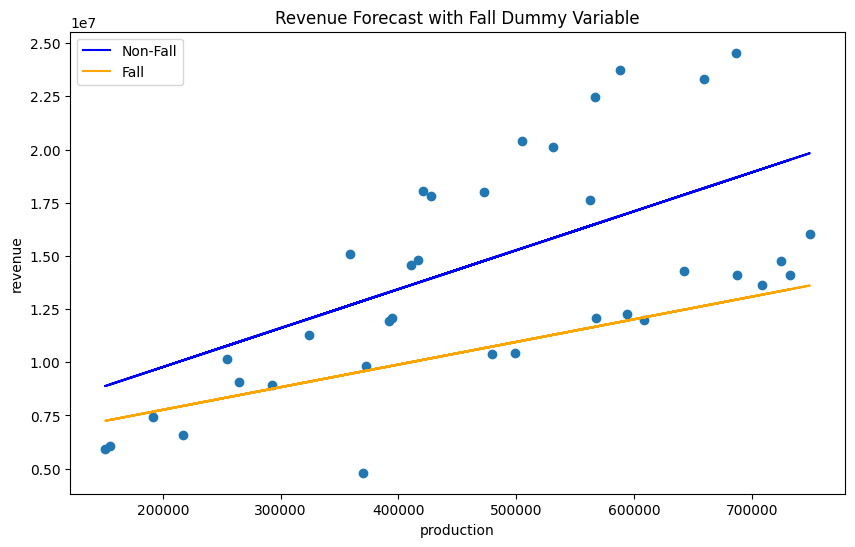

In [ ]:
plt.figure(figsize=(10, 6))

plt.title('Revenue Forecast with Fall Dummy Variable')
plt.xlabel('production')
plt.ylabel('revenue')

#Step 1: scatter plot the actual data points
plt.scatter(dt4training['production'], dt4training['revenue'])

#Step 2: extract coefficients
intercept, production_coefficient, fall_DV_intercept, fall_coefficient = modelA.params

#Step 3: build separate lines for fall and non-fall
non_fall_line = intercept + production_coefficient * dt4training['production']
fall_line = (intercept + fall_DV_intercept) + (production_coefficient + fall_coefficient) * dt4training['production']

#Step 4: plot both lines
plt.plot(dt4training['production'], non_fall_line, color='blue', label='Non-Fall')
plt.plot(dt4training['production'], fall_line, color='orange', label='Fall')
plt.legend()

Model 2: production + spring dummy + spring interaction

In [ ]:
xB = dt4training.loc[:, ['production', 'spring_DV', 'spring_interaction']]
xB = sm.add_constant(xB)

modelB = sm.OLS(y, xB).fit()

modelB.params

,0
const,5645359.67
production,17.00
spring_DV,-6781361.28
spring_interaction,23.65


revenue = 5,645,360 + 17.00 * production - 6,781,361 * spring + 23.65 * production * spring

Non-spring months equation:
revenue = 5,645,360 + 17.00 * production

Spring months equation:
revenue = 5,645,360 + 17.00 * production - 6,781,361 + 23.65 * production
        = -1,136,001 + 40.65 * production

In [ ]:
xB_test = dt4testing.loc[:, ['production', 'spring_DV', 'spring_interaction']]
xB_test = sm.add_constant(xB_test)

modelB_assessment = dt4testing.copy()

modelB_assessment['predicted_revenue'] = modelB.predict(xB_test)

modelB_assessment['abs_pct_error'] = abs(
    (modelB_assessment['revenue'] - modelB_assessment['predicted_revenue']) / modelB_assessment['revenue'])

display(modelB_assessment)

,type,date,revenue,production,coolDD,heatDD,spring_DV,fall_DV,spring_interaction,fall_interaction,predicted_revenue,abs_pct_error
36,dt4testing,2014-01-31,19228840,606400,0,1123,0,0,0,0,15954706.09,0.17
37,dt4testing,2014-02-28,26792280,714128,0,938,0,0,0,0,17786179.17,0.34
38,dt4testing,2014-03-31,19935840,805600,0,866,1,0,805600,0,31615584.53,0.59
39,dt4testing,2014-04-30,13468000,375856,0,412,1,0,375856,0,14144385.88,0.05
40,dt4testing,2014-05-31,7344128,279296,49,88,1,0,279296,0,10218748.89,0.39
41,dt4testing,2014-06-30,11196216,517600,230,0,0,0,0,0,14445026.08,0.29
42,dt4testing,2014-07-31,13929472,749472,380,0,0,0,0,0,18387059.02,0.32
43,dt4testing,2014-08-31,12352176,663432,322,0,0,0,0,0,16924301.49,0.37
44,dt4testing,2014-09-30,12628944,701656,178,14,0,1,0,701656,17574143.93,0.39
45,dt4testing,2014-10-31,9361000,411728,24,166,0,1,0,411728,12645106.68,0.35


In [ ]:
modelB_assessment['abs_pct_error'].mean()

np.float64(0.2892751835381226)

MAPE score = 28.93%

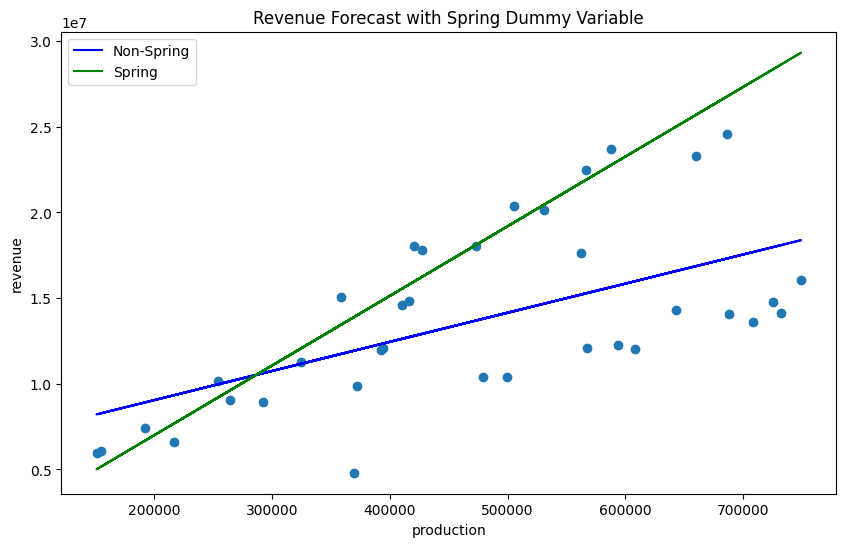

In [ ]:
plt.figure(figsize=(10, 6))

plt.title('Revenue Forecast with Spring Dummy Variable')
plt.xlabel('production')
plt.ylabel('revenue')

plt.scatter(dt4training['production'], dt4training['revenue'])

intercept, production_coefficient, spring_DV_intercept, spring_coefficient = modelB.params

non_spring_line = intercept + production_coefficient * dt4training['production']
spring_line = (intercept + spring_DV_intercept) + (production_coefficient + spring_coefficient) * dt4training['production']

plt.plot(dt4training['production'], non_spring_line, color='blue', label='Non-Spring')
plt.plot(dt4training['production'], spring_line, color='green', label='Spring')
plt.legend()

Comparison: MAPE scores for model 1 vs. model 2

<BarContainer object of 2 artists>

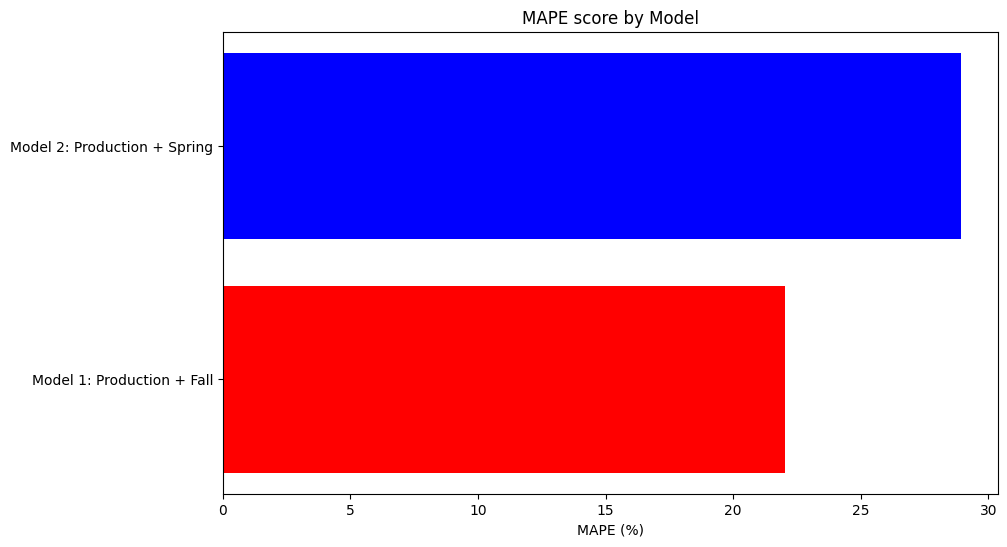

In [ ]:
model_names = ['Model 1: Production + Fall', 'Model 2: Production + Spring']

mape_scores = [modelA_assessment['abs_pct_error'].mean() * 100,
               modelB_assessment['abs_pct_error'].mean() * 100]

plt.figure(figsize=(10, 6))

plt.title('MAPE score by Model')
plt.xlabel('MAPE (%)')

plt.barh(model_names, mape_scores, color = ['red', 'blue'])

To: H&A Management

From: Analyst, Quantfolio Solutions

Re: Seasonal Revenue Forecasting Recommendation

Based on developing and testing 2 revenue forecasting models, using production with a seasonal dummy variable and interaction, we recommend a Fall forecasting model.

Our analysis included a model based on the Fall months (September, October, and November) and the Spring months (March, April, and May). Each model was trained on historical data (dt4training) and testing data (dt4testing) with MAPE score as the accuracy metric.

Model 1: MAPE = 22.02%
Model 2: MAPE = 28.93%

We recommend using Model 1, the stronger forecasting model, as it has a lower MAPE score (22.02% < 28.93%).

As a next step, we recommend developing and testing additional models (e.g. combining multiple seasons, or using coolDD or heatDD with the seasonal dummies) to see if any models are more accurate.